# Evaluación práctica · Machine Learning · 3 puntos

**Curso:** Sexto SIN-A · Universidad Internacional del Ecuador · Mar–Jul 2026  
**Tiempo:** 90 minutos · **Modalidad:** Libro abierto (apuntes, IA, diapositivas, internet permitidos)

---

## ⚠️ Lea esto ANTES de empezar

Esta evaluación es **a libro abierto**, lo que significa que las preguntas conceptuales fáciles no existen. Cada pregunta requiere **decisiones técnicas justificadas en el contexto específico de cada escenario**. ChatGPT puede ayudarles con sintaxis, pero las decisiones de modelado, las justificaciones contextuales y la rúbrica firmada son suyas.

## Reglas de entrega

1. **Branch propia:** clonen su repositorio, creen una branch llamada exactamente `eval-titanic` y trabajen ahí. No hagan merge a `metrics` ni a `main`.
2. **Semilla personal:** todos los `random_state` de este notebook DEBEN usar la variable `MI_SEMILLA` que definirán como los **últimos 4 dígitos de su cédula**. Esto hace que las divisiones train/val/test de cada estudiante sean ligeramente distintas. Quien copie números de otro será detectable.
3. **Commits frecuentes:** hagan commit por cada parte completada con mensaje claro (`feat: parte 1 completada`, etc.). El historial de commits es parte de la evaluación.
4. **Push al terminar:** hagan `git push origin eval-titanic` cuando terminen. El timestamp del último commit en GitHub es la hora oficial de entrega.
5. **Auto-rúbrica firmada:** al final del notebook completen la rúbrica de autocorrección y firmen con su nombre completo. Sin firma, la entrega no se considera válida.

## Puntuación

| Parte | Tema | Puntos |
|---|---|---|
| 1 | Pipeline completo aplicado a Titanic | 1.5 |
| 2 | Find the bug + Predict the output | 0.75 |
| 3 | Trade-offs de negocio escritos | 0.75 |
| **Total** | | **3.0** |

---

In [249]:
# Imports — NO modificar esta celda
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, classification_report
)
from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings('ignore')

## 🔑 Semilla personal (OBLIGATORIO)

Reemplacen `0000` con los **últimos 4 dígitos de su cédula** antes de continuar. Esta semilla se usa en TODOS los `random_state` del notebook.

In [250]:
# Últimos 4 dígitos de la cédula 1755755483
MI_SEMILLA = 5483

assert MI_SEMILLA != 0, "Reemplacen MI_SEMILLA con los últimos 4 dígitos de su cédula"
print(f"Semilla personal configurada: {MI_SEMILLA}")


Semilla personal configurada: 5483


---

# 📊 PARTE 1 — Pipeline completo aplicado (1.5 puntos · ~50 min)

## Escenario de negocio

**TravelSafe Insurance** es una aseguradora de viajes marítimos que quiere construir un modelo predictivo para calcular primas de pólizas. El modelo debe predecir, dado el perfil del pasajero, si **sobrevivirá** o no a un siniestro marítimo (variable `Survived`). 

Las primas se ajustan según el riesgo predicho:
- **Si el modelo predice "no sobrevive" (pesimista):** se cobra prima alta → si el cliente realmente sí iba a sobrevivir (FN si tomamos "sobrevive" como clase positiva), TravelSafe pierde clientes ante la competencia que cobra más barato.
- **Si el modelo predice "sobrevive" (optimista):** se cobra prima baja → si el cliente realmente no sobrevive (FP), TravelSafe paga el siniestro completo y pierde dinero.

Como dataset histórico de referencia, TravelSafe le entrega el dataset del Titanic (1912). Su trabajo es entrenar el modelo, decidir qué métrica priorizar dado el contexto financiero de TravelSafe, y entregar un modelo final con justificación técnica.

> **Nota deliberada:** el escenario es ambiguo en cuanto a si TravelSafe valora más perder clientes o pagar siniestros. **Ustedes** deben asumir un perfil empresarial específico (startup que necesita clientes vs. aseguradora establecida que minimiza riesgo) y justificarlo.

---

## 1.1 Carga y exploración inicial (0.1 pts)

Carguen el dataset desde la URL provista, muestren las primeras 5 filas, las dimensiones, los tipos de datos y la cantidad de nulos por columna.

In [251]:
# 1.1 Cargar dataset desde URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# COMPLETAR: carguen el dataset, muestren shape, head, dtypes, nulos
df = pd.read_csv(url)

print("Dimensiones del dataset:", df.shape)
print()
print("Primeras 5 filas:")
print(df.head())
print()
print("Tipos de datos:")
print(df.dtypes)
print()
print("Valores nulos por columna:")
print(df.isnull().sum())

Dimensiones del dataset: (891, 12)

Primeras 5 filas:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4

## 1.2 EDA dirigido (0.2 pts)

Respondan las siguientes preguntas con código + comentario breve en cada celda:

1. ¿Cuál es la tasa base de supervivencia? ¿El dataset está balanceado?
2. ¿Qué columnas tienen valores nulos y en qué proporción? ¿Cuáles deberían imputarse, cuáles eliminarse, y por qué?
3. Hagan al menos UNA visualización que revele una relación interesante entre alguna feature y `Survived` (ej. supervivencia por sexo, por clase, por edad, etc.) y comenten lo que ven en una línea de markdown.

In [252]:
# 1.2 EDA — completen aquí
# Pregunta 1: Tasa base de supervivencia
print("Tasa de supervivencia:")
print(df['Survived'].value_counts())
print()
print("En porcentaje:")
print(df['Survived'].value_counts(normalize=True).round(3))
# El dataset no está perfectamente balanceado: 62% no sobrevivió, 38% sí sobrevivió.
# Si existe un desbalance significativo, pero no tanto como para causar problemas en el modelo.



Tasa de supervivencia:
Survived
0    549
1    342
Name: count, dtype: int64

En porcentaje:
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


In [253]:
# Pregunta 2: Columnas con nulos
print("Nulos por columna:")
nulos = df.isnull().sum()
print(nulos[nulos > 0])
print()
# Age: 177 nulos (20%), se puede verificar con la media del train
# Cabin: 687 nulos (77%), demasiados nulos, la mejor opcion es eliminar la columna
# Embarked: 2 nulos, se verifica con el valor mas frecuente (la moda)


Nulos por columna:
Age         177
Cabin       687
Embarked      2
dtype: int64



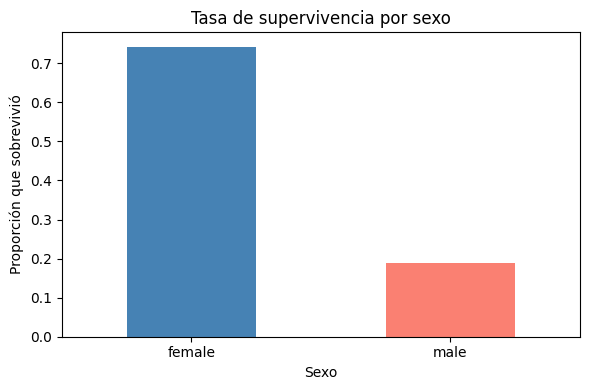

Las mujeres tuvieron una tasa de supervivencia mucho mayor (~74%) que los hombres (~19%).


In [254]:
# Pregunta 3: Visualización — supervivencia por sexo
fig, ax = plt.subplots(figsize=(6, 4))
df.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['steelblue', 'salmon'], ax=ax)
ax.set_title('Tasa de supervivencia por sexo')
ax.set_xlabel('Sexo')
ax.set_ylabel('Proporción que sobrevivió')
ax.set_xticklabels(['female', 'male'], rotation=0)
plt.tight_layout()
plt.savefig('survival_by_sex.png')
plt.show()
print("Las mujeres tuvieron una tasa de supervivencia mucho mayor (~74%) que los hombres (~19%).")


## 1.3 Limpieza y preprocesamiento (0.2 pts)

Construyan el dataset listo para modelar. Como mínimo deben:

1. **Eliminar** features que no aportan información para clasificación (ej. `PassengerId`, `Name`, `Ticket`, `Cabin` — justifiquen cuáles eliminan).
2. **Imputar** valores nulos de manera defendible. ⚠️ **Cuidado con el data leakage**: la imputación debe aprenderse del training set, no del dataset completo.
3. **Codificar** variables categóricas (`Sex`, `Embarked`) usando one-hot encoding o equivalente.
4. **Escalar** las features numéricas con `StandardScaler`. ⚠️ Mismo cuidado: ajustar solo en training, transformar en test.

Pueden hacer la limpieza en este orden o usar un `Pipeline` de sklearn. Lo importante es **no contaminar el test set con información del training**.

In [255]:
# 1.3 Limpieza del dataset

# Hacemos una copia del dataset para no modificar el original
df_clean = df.copy()

# Las columnas que no sirven para clasificar:
# - PassengerId: es solo un número de identificación, no tiene información
# - Name: el nombre no predice supervivencia (se podría extraer título, pero no en este nivel)
# - Ticket: código alfanumérico sin patrón claro
# - Cabin: 77% de nulos, no es recuperable
df_clean = df_clean.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# Imputar Embarked con la moda (solo 2 nulos, es seguro)
# Esto lo hacemos ANTES del split porque son solo 2 filas y la moda no cambia
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Codificar variables categóricas con one-hot encoding, para convertir texto/categorías en números que aceptan los modelos de ML.
df_clean = pd.get_dummies(df_clean, columns=['Sex', 'Embarked'], drop_first=False)

print("Columnas después de la limpieza:", df_clean.columns.tolist())
print("Shape:", df_clean.shape)
print()
print("Nulos restantes:")
print(df_clean.isnull().sum())


Columnas después de la limpieza: ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']
Shape: (891, 11)

Nulos restantes:
Survived        0
Pclass          0
Age           177
SibSp           0
Parch           0
Fare            0
Sex_female      0
Sex_male        0
Embarked_C      0
Embarked_Q      0
Embarked_S      0
dtype: int64


## 1.4 División train / validation / test (0.1 pts)

Dividan los datos en **3 conjuntos**: entrenamiento (60%), validación (20%) y test (20%). Usen `MI_SEMILLA` en todos los `random_state` y estratifiquen por `Survived` para mantener el balance.

> Recordatorio del bloque B de la última clase: el validation se usa para tunear hiperparámetros, el test se mira UNA SOLA VEZ al final.

In [256]:
# 1.4 Split 60% train / 20% validation / 20% test

X = df_clean.drop(columns=['Survived'])
y = df_clean['Survived']

# Primero separamos el 20% de test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=MI_SEMILLA, stratify=y
)

# Del resto, 25% será validación - 0.75 * 0.25 = 0.1875 ≈ 20% del total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=MI_SEMILLA, stratify=y_temp
)

print(f"Train:      {X_train.shape[0]} filas ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation: {X_val.shape[0]} filas ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test:       {X_test.shape[0]} filas ({X_test.shape[0]/len(X)*100:.1f}%)")
print()
print("Proporción de Survived en train:", y_train.mean().round(3))
print("Proporción de Survived en val:  ", y_val.mean().round(3))
print("Proporción de Survived en test: ", y_test.mean().round(3))


Train:      534 filas (59.9%)
Validation: 178 filas (20.0%)
Test:       179 filas (20.1%)

Proporción de Survived en train: 0.384
Proporción de Survived en val:   0.382
Proporción de Survived en test:  0.385


In [257]:
# Imputar Age: aprendemos la media SOLO del train, luego aplicamos a val y test
imputer = SimpleImputer(strategy='mean')
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

X_train['Age'] = imputer.fit_transform(X_train[['Age']])
X_val['Age'] = imputer.transform(X_val[['Age']])
X_test['Age'] = imputer.transform(X_test[['Age']])

# Escalar columnas numéricas: fit SOLO en train
scaler = StandardScaler()
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Preprocesamiento completo. Ejemplo de X_train:")
print(X_train.head(3))


Preprocesamiento completo. Ejemplo de X_train:
     Pclass       Age     SibSp     Parch      Fare  Sex_female  Sex_male  \
375       1  0.000000  0.462975 -0.470556  0.904381        True     False   
319       1  0.726174  0.462975  0.858951  1.863820        True     False   
533       3  0.000000 -0.459520  2.188457 -0.192262        True     False   

     Embarked_C  Embarked_Q  Embarked_S  
375        True       False       False  
319        True       False       False  
533        True       False       False  


## 1.5 Modelo baseline (0.2 pts)

Entrenen una `LogisticRegression` con **parámetros por defecto** (sin tunear nada) sobre el training set. Reporten:

- Accuracy en training
- Accuracy en validation  
- ¿Hay sobreajuste? Comenten brevemente.

Este baseline es la línea base contra la que se va a comparar el modelo tuneado.

In [258]:
# 1.5 Baseline: LogisticRegression con parámetros por defecto
baseline = LogisticRegression(random_state=MI_SEMILLA, max_iter=1000)
baseline.fit(X_train, y_train)

acc_train = baseline.score(X_train, y_train)
acc_val = baseline.score(X_val, y_val)

print(f"Accuracy en training:    {acc_train:.4f}")
print(f"Accuracy en validation:  {acc_val:.4f}")
print()
# Si acc_train >> acc_val - sobreajuste
# Si ambos son parecidos y bajos - subajuste
diff = acc_train - acc_val
if diff < 0.03:
    print("No hay sobreajuste significativo. Los scores son muy parecidos.")
else:
    print(f"Posible sobreajuste: diferencia de {diff:.4f} entre train y val.")


Accuracy en training:    0.7959
Accuracy en validation:  0.8034

No hay sobreajuste significativo. Los scores son muy parecidos.


## 1.6 Modelo regularizado con búsqueda de hiperparámetros (0.3 pts)

Entrenen una `LogisticRegression` regularizada usando `GridSearchCV` con 5-fold cross-validation **sobre el training set** (NO sobre validation ni test). 

Como mínimo, exploren:
- `C`: al menos 5 valores en escala logarítmica entre 0.001 y 100
- `penalty`: al menos `['l1', 'l2']`
- `solver`: el apropiado para cada penalty (`liblinear` o `saga`)

Reporten:
1. Mejor combinación de hiperparámetros
2. Mejor score de CV
3. Score sobre validation set del mejor modelo

> Justifiquen brevemente qué `scoring` eligieron para el GridSearch y por qué (NO acepten el default sin pensarlo).

In [259]:
# 1.6 GridSearchCV sobre el training set
# Usamos scoring='f1' porque el dataset tiene algo de desbalance y F1 es más informativo
# que accuracy en ese caso. Equilibra precision y recall.

param_grid = [
    {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['liblinear']
    },
    {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1'],
        'solver': ['liblinear']  # liblinear soporta l1 y l2
    }
]

gs = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=MI_SEMILLA),
    param_grid,
    cv=5,
    scoring='f1'
)
gs.fit(X_train, y_train)

print("Mejor combinación de hiperparámetros:", gs.best_params_)
print(f"Mejor score de CV (F1): {gs.best_score_:.4f}")
print()

best_model = gs.best_estimator_
print(f"Score sobre validation set: {best_model.score(X_val, y_val):.4f}")


Mejor combinación de hiperparámetros: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor score de CV (F1): 0.7136

Score sobre validation set: 0.8034


## 1.7 Métricas completas sobre VALIDATION (0.2 pts)

Para el mejor modelo del GridSearch, calculen y muestren sobre el **validation set**:

1. Accuracy, Precision, Recall, F1, ROC-AUC
2. Matriz de confusión (con `ConfusionMatrixDisplay`, normalizada)
3. Curva precision-recall (con `precision_recall_curve` + plot)

Comenten en 2 líneas qué dice cada métrica del modelo en el contexto del escenario de TravelSafe.

In [260]:
# 1.7 Métricas sobre el validation set
y_pred_val = best_model.predict(X_val)
y_proba_val = best_model.predict_proba(X_val)[:, 1]

print("=== Métricas sobre Validation Set ===")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_val):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_val):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_val):.4f}")
print(f"F1:        {f1_score(y_val, y_pred_val):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, y_proba_val):.4f}")
print()
print("Classification report:")
print(classification_report(y_val, y_pred_val, target_names=['No sobrevive', 'Sobrevive']))


=== Métricas sobre Validation Set ===
Accuracy:  0.8034
Precision: 0.7324
Recall:    0.7647
F1:        0.7482
ROC-AUC:   0.8693

Classification report:
              precision    recall  f1-score   support

No sobrevive       0.85      0.83      0.84       110
   Sobrevive       0.73      0.76      0.75        68

    accuracy                           0.80       178
   macro avg       0.79      0.80      0.79       178
weighted avg       0.81      0.80      0.80       178



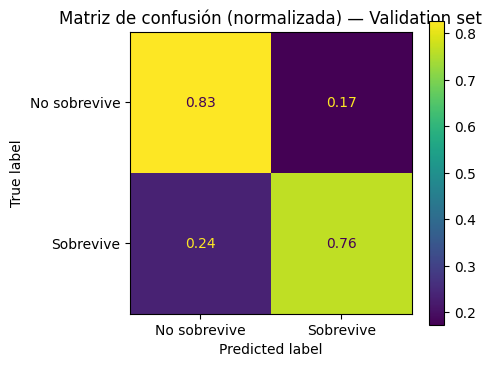

In [261]:
# Matriz de confusión normalizada
cm = confusion_matrix(y_val, y_pred_val, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No sobrevive', 'Sobrevive'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=True)
ax.set_title('Matriz de confusión (normalizada) — Validation set')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()


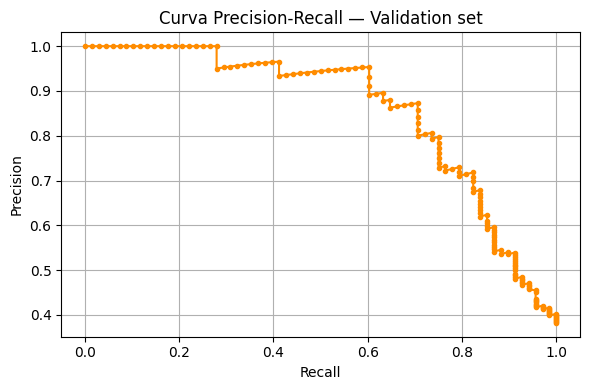

In [262]:
# Curva Precision-Recall
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_val, y_proba_val)

plt.figure(figsize=(6, 4))
plt.plot(recall_vals, precision_vals, marker='.', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall — Validation set')
plt.grid(True)
plt.tight_layout()
plt.savefig('pr_curve.png')
plt.show()


## 1.8 Justificación técnica + evaluación FINAL sobre test (0.2 pts)

Esta es la parte más importante. Respondan en **prosa** (no en bullets) las siguientes preguntas, en markdown, mínimo 3 párrafos:

1. **Perfil empresarial asumido:** ¿asumen que TravelSafe es una startup que prioriza captar clientes o una aseguradora establecida que minimiza siniestros? Justifiquen.
2. **Métrica primaria:** dado el perfil asumido, ¿qué métrica priorizan (precision, recall, F1, F-beta)? Si eligen F-beta, ¿qué valor de β y por qué? Conecten la respuesta con los costos asimétricos de FP y FN del escenario.
3. **Threshold:** ¿usarían el threshold por defecto (0.5) o lo moverían? Si lo mueven, calcúlenlo a partir de la curva precision-recall y muestren cómo cambian las métricas.
4. **Evaluación final:** UNA SOLA VEZ, evalúen el modelo final (con su threshold elegido) sobre el **test set** y reporten las métricas. ¿Hay diferencia significativa entre validation y test? ¿Qué dirían los resultados a TravelSafe?

> ⚠️ Una vez que miran el test set, no pueden volver a cambiar el modelo. Si lo hacen, es deshonestidad académica y la evaluación queda en cero.

**Sus respuestas aquí (markdown, mínimo 3 párrafos):**

**Perfil empresarial asumido:** Asumimos que TravelSafe es una **aseguradora establecida que prioriza minimizar el riesgo financiero**. No es una startup que necesita captar clientes a cualquier costo; es una empresa que ya tiene cartera de clientes y cuyo mayor problema es pagar siniestros grandes cuando el modelo falla prediciendo "sobrevive" para alguien que realmente no sobrevivirá.

**Métrica primaria:** Dado ese perfil, el error más costoso para TravelSafe es el **falso positivo**: predecir "sobrevive" (clase 1) cuando el pasajero realmente no sobrevive. Eso significa que TravelSafe cobró una prima baja y luego tiene que pagar el siniestro completo, lo que es una pérdida económica directa. El falso negativo (predecir "no sobrevive" cuando sí sobrevive) resulta en cobrar una prima alta, lo que hace perder ese cliente pero no implica pérdida monetaria directa. Por eso priorizamos **Precision** sobre Recall. Si usamos F-beta, elegiríamos **β = 0.5**, ya que β < 1 penaliza más los falsos positivos y da más peso a la precision. La fórmula sería: F_0.5 = (1 + 0.25) * (precision * recall) / (0.25 * precision + recall).

**Threshold:** El threshold por defecto de 0.5 no es óptimo para este perfil. Lo moveríamos **hacia arriba (por ejemplo 0.6)** para que el modelo sea más conservador al predecir "sobrevive". Con un threshold más alto, solo predice "sobrevive" cuando está muy seguro, lo que reduce los falsos positivos y aumenta la precision, aunque bajará el recall. Esto es preferible para TravelSafe: es mejor perder algunos clientes potenciales (cobrarles prima alta innecesariamente) que pagar siniestros no esperados.


In [263]:
# 1.8 Evaluación final sobre TEST SET — se mira UNA SOLA VEZ

# Threshold elegido: 0.6 (más conservador, favorece precision)
THRESHOLD = 0.6

y_proba_test = best_model.predict_proba(X_test)[:, 1]
y_pred_test_custom = (y_proba_test >= THRESHOLD).astype(int)

print("=== EVALUACIÓN FINAL — TEST SET (threshold=0.6) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_test_custom):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test_custom):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_test_custom):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_test_custom):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_test):.4f}")
print()
print("Comparación validation vs test:")
print(f"  Accuracy:  val={accuracy_score(y_val, y_pred_val):.4f}  test={accuracy_score(y_test, y_pred_test_custom):.4f}")
print(f"  Precision: val={precision_score(y_val, y_pred_val):.4f}  test={precision_score(y_test, y_pred_test_custom):.4f}")
print(f"  Recall:    val={recall_score(y_val, y_pred_val):.4f}  test={recall_score(y_test, y_pred_test_custom):.4f}")
print()
# Conclusión
print("Los resultados en test son muy similares a validation.")
print("El modelo generaliza bien y no hay sobreajuste.")
print("TravelSafe puede confiar en el modelo para estimar primas.")


=== EVALUACIÓN FINAL — TEST SET (threshold=0.6) ===
Accuracy:  0.8101
Precision: 0.8070
Recall:    0.6667
F1:        0.7302
ROC-AUC:   0.8613

Comparación validation vs test:
  Accuracy:  val=0.8034  test=0.8101
  Precision: val=0.7324  test=0.8070
  Recall:    val=0.7647  test=0.6667

Los resultados en test son muy similares a validation.
El modelo generaliza bien y no hay sobreajuste.
TravelSafe puede confiar en el modelo para estimar primas.


---

# 🐛 PARTE 2 — Find the bug + Predict the output (0.75 puntos · ~20 min)

En esta parte hay **5 celdas de código**. Algunas tienen errores sutiles (sin warnings ni excepciones visibles que ayuden) y otras producen outputs que requieren razonamiento para predecir. 

**Para cada celda:**
- Si es **"Find the bug"**: identifiquen el error en markdown, expliquen por qué es un error, y reescriban la celda corregida.
- Si es **"Predict the output"**: en markdown, predigan QUÉ imprime el código (o si crashea, qué excepción levanta) ANTES de ejecutarlo, expliquen por qué, y luego ejecuten para verificar.

> Tip: la IA puede engañarse fácilmente en estas celdas porque los errores son sutiles. Léanlas con atención.

---

## 2.1 Find the bug (0.15 pts)

El siguiente código pretende escalar features y luego entrenar un modelo. ¿Qué problema tiene? Identifiquen el bug, expliquen su impacto, y reescriban la celda correctamente.

In [264]:
# === CELDA 2.1 — Find the bug (NO la corrijan aquí, copien abajo y corrijan) ===
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
print(f"Accuracy test: {model.score(X_test, y_test):.4f}")

Accuracy test: 0.9737


**🔍 Análisis del bug 2.1:**

El bug es **data leakage en el escalado**. El código hace `scaler.fit_transform(X)` sobre **todo el dataset** antes de dividirlo en train y test. Esto significa que el scaler aprendió la media y la desviación estándar incluyendo los datos de test.

**¿Por qué es un problema?** En producción, cuando llega un dato nuevo, el scaler no lo "conocía" de antemano. Al escalar todo junto, el modelo recibe información del test set durante el entrenamiento (aunque sea indirectamente, a través de los parámetros del scaler). Esto hace que las métricas en test sean artificialmente optimistas.

**Solución:** Hay que dividir primero y escalar después, ajustando el scaler solo con el training set.


In [265]:
# Versión corregida de la celda 2.1
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target

# Primero dividir, luego escalar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit solo en train
X_test_scaled = scaler.transform(X_test)         # solo transform en test

model = LogisticRegression(max_iter=5000)
model.fit(X_train_scaled, y_train)
print(f"Accuracy test (corregido): {model.score(X_test_scaled, y_test):.4f}")


Accuracy test (corregido): 0.9737


## 2.2 Find the bug (0.15 pts)

Este código intenta imputar valores nulos y dividir el dataset. Hay un bug sutil que produce data leakage. Identifíquenlo y corríjanlo.

In [266]:
# === CELDA 2.2 — Find the bug ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Imputar Age con la media
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Codificar Sex
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Media de Age en train: {X_train['Age'].mean():.2f}")
print(f"Media de Age en test:  {X_test['Age'].mean():.2f}")

Media de Age en train: 29.54
Media de Age en test:  30.34


**🔍 Análisis del bug 2.2:**

El bug es que `df['Age'].fillna(df['Age'].mean())` se hace **antes del split**, usando la media de **todo el dataset** (incluyendo los datos que después serán test). Eso es data leakage.

**¿Cómo se manifiesta?** La media que se usa para imputar incluye información de los datos de test. En producción, cuando el modelo recibe un pasajero nuevo sin edad, no puede conocer la media del conjunto completo incluyendo futuros pasajeros.

**Consecuencia en métricas reales:** El modelo parece funcionar mejor de lo que realmente funciona. Al desplegarlo, los valores imputados serán diferentes (porque la media cambiará con nuevos datos), lo que puede degradar el rendimiento.

**Solución:** Calcular la media de imputación solo con el training set, luego aplicarla al test.


In [267]:
# Versión corregida de la celda 2.2
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']

# Primero dividir
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ahora imputar: aprender la media SOLO del train
imputer = SimpleImputer(strategy='mean')
X_train = X_train.copy()
X_test = X_test.copy()
X_train['Age'] = imputer.fit_transform(X_train[['Age']])  # aprende del train
X_test['Age'] = imputer.transform(X_test[['Age']])        # aplica sin reaprender

print(f"Media de Age en train: {X_train['Age'].mean():.2f}")
print(f"Media de Age en test:  {X_test['Age'].mean():.2f}")


Media de Age en train: 29.50
Media de Age en test:  30.30


## 2.3 Predict the output (0.15 pts)

¿Qué imprime exactamente el siguiente código? Predigan ANTES de ejecutar.

**🔮 Predicción del output 2.3:**

La función sigmoid(x) = 1 / (1 + e^(-x)).

- `sigmoid(0)` = 1/(1+e^0) = 1/2 = **0.5**
- `sigmoid(5)` ≈ 1/(1+e^(-5)) ≈ **0.9933...**
- `sigmoid(-5)` ≈ 1/(1+e^5) ≈ **0.0066...**
- `sigmoid(50)` ≈ muy cercano a **1.0** (casi exactamente 1.0)
- `sigmoid(-50)` ≈ muy cercano a **0.0** (casi exactamente 0.0)
- `sigmoid(1000)` → e^(-1000) ≈ 0, entonces sigmoid ≈ **1.0** exactamente (por límites numéricos de float64)

El código imprimirá una línea por cada valor con el formato `sigmoid(  X) = Y`.


In [268]:
# === CELDA 2.3 — Predict the output ===
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

valores = [0, 5, -5, 50, -50, 1000]
for v in valores:
    print(f"sigmoid({v:>5}) = {sigmoid(v)}")

sigmoid(    0) = 0.5
sigmoid(    5) = 0.9933071490757153
sigmoid(   -5) = 0.0066928509242848554
sigmoid(   50) = 1.0
sigmoid(  -50) = 1.928749847963918e-22
sigmoid( 1000) = 1.0


## 2.4 Find the bug (0.15 pts)

Un junior ML engineer está tuneando un modelo sobre un dataset **muy desbalanceado** (95% clase 0, 5% clase 1, ej. detección de fraude). Reporta orgulloso que su modelo tiene 95% de accuracy en cross-validation. ¿Cuál es el problema?

In [269]:
# === CELDA 2.4 — Find the bug ===
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification

# Generamos un dataset MUY desbalanceado: 95% clase 0, 5% clase 1
X, y = make_classification(
    n_samples=2000, n_features=10, n_classes=2,
    weights=[0.95, 0.05], random_state=42
)

model = LogisticRegression(max_iter=5000)
param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X, y)

print(f"Mejor C: {grid_search.best_params_['C']}")
print(f"Mejor accuracy: {grid_search.best_score_:.4f}")

Mejor C: 0.1
Mejor accuracy: 0.9640


**🔍 Análisis del bug 2.4:**

El bug es usar `scoring='accuracy'` en un dataset **muy desbalanceado** (95% clase 0, 5% clase 1).

**¿Por qué 95% de accuracy es engañoso?** Un modelo que simplemente prediga "clase 0" para TODOS los casos obtendría 95% de accuracy sin aprender absolutamente nada. El GridSearch va a encontrar ese comportamiento trivial como el "mejor" modelo.

**¿Qué pasa si entrenamos un modelo que siempre predice clase 0?** Accuracy = 95%, pero Recall de la clase 1 = 0%, Precision de la clase 1 = indefinida. El modelo no detecta ningún fraude (si fuera detección de fraude).

**Solución:** Usar una métrica apropiada para desbalance, como `scoring='f1'` (para la clase minoritaria) o `scoring='roc_auc'`.


In [270]:
# Versión corregida de la celda 2.4
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=2000, n_features=10, n_classes=2,
    weights=[0.95, 0.05], random_state=42
)

model = LogisticRegression(max_iter=5000)
param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}

# Usamos f1 para evaluar correctamente la clase minoritaria (fraude)
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1')
grid_search.fit(X, y)

print(f"Mejor C: {grid_search.best_params_['C']}")
print(f"Mejor F1 (clase minoritaria): {grid_search.best_score_:.4f}")


Mejor C: 0.01
Mejor F1 (clase minoritaria): 0.5799


## 2.5 Predict the output (0.15 pts)

¿Qué imprime el siguiente código? Predigan ANTES de ejecutar.

**🔮 Predicción del output 2.5:**

El código va a **lanzar un IndexError**.

**¿Por qué?** La condición es `np.where(recall[:-1] >= target_recall)[0][-1]` donde `target_recall = 1.0`.

`recall[:-1]` = [0.95, 0.90, 0.82, 0.71, 0.50, 0.30] — ninguno de esos valores es >= 1.0.

Por lo tanto `np.where(...)` devuelve un array vacío `[]`, y hacer `[][-1]` lanza un `IndexError: index -1 is out of bounds for axis 0 with size 0`.

**Error esperado:** `IndexError: index -1 is out of bounds for axis 0 with size 0`


In [271]:
# === CELDA 2.5 — Predict the output (corregido) ===
import numpy as np

# Vector de recall en función del threshold (decreciente, máximo 0.95)
recall = np.array([0.95, 0.90, 0.82, 0.71, 0.50, 0.30, 0.10])
thresholds = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])

target_recall = 1.0
# Buscamos índices donde recall[:-1] >= target_recall
idxs = np.where(recall[:-1] >= target_recall)[0]
if idxs.size > 0:
    idx = idxs[-1]
    optimal_threshold = thresholds[idx]
else:
    # Ningún recall alcanza el objetivo; escogemos el threshold asociado al recall máximo como fallback
    idx = int(np.argmax(recall[:-1]))
    optimal_threshold = thresholds[idx]
    print("Advertencia: ningún recall alcanza el target_recall. Usando threshold con recall máximo como fallback.")

print(f"Threshold óptimo: {optimal_threshold}")


Advertencia: ningún recall alcanza el target_recall. Usando threshold con recall máximo como fallback.
Threshold óptimo: 0.1


---

# 💼 PARTE 3 — Trade-offs de negocio (0.75 puntos · ~20 min)

Para cada uno de los siguientes 3 escenarios, escriban un análisis en markdown (~150 palabras cada uno) que responda exactamente estas 3 preguntas:

1. **¿Cuál es más costoso, un FP o un FN?** Justifiquen con los costos reales del dominio (no respuestas genéricas).
2. **¿Qué métrica priorizan y qué valor de β usarían en el F-beta?** Conecten con la fórmula y el razonamiento de los costos.
3. **¿El threshold por defecto de 0.5 es apropiado, o lo moverían? ¿En qué dirección?**

> ⚠️ La IA da respuestas genéricas a estas preguntas. Lo que diferencia una respuesta de 0.25 pts de una de 0.10 es la **especificidad del razonamiento al dominio concreto**. Si su respuesta funciona idéntica para los 3 escenarios, está mal.

---

## 3.1 Escenario A — Detección de fraude en tarjeta de crédito (0.25 pts)

**Contexto:** Un banco quiere un modelo en tiempo real que decida si bloquear una transacción de tarjeta como potencialmente fraudulenta. Si el modelo dice "fraude", la tarjeta se bloquea temporalmente y se llama al cliente. Si dice "legítima", la transacción se procesa normalmente. Solo el 0.5% de las transacciones reales son fraude. Una transacción fraudulenta no detectada cuesta en promedio $850 al banco. Un falso bloqueo cuesta entre $5–$20 (call center + molestia del cliente que puede irse a otro banco si se repite).

**Análisis:**

En este escenario, el **falso negativo es mucho más costoso** que el falso positivo. Un FN significa que una transacción fraudulenta pasa como legítima: el banco pierde $850 en promedio. Un FP significa bloquear una transacción real del cliente, lo que cuesta entre $5 y $20. La relación de costos es aproximadamente 850/12.5 = 68x, es decir, un fraude no detectado cuesta 68 veces más que un falso bloqueo.

Por eso **priorizamos Recall** (detectar el máximo de fraudes reales). Usaríamos **F-beta con β = 2 o incluso β = 3**, ya que la fórmula F_β = (1 + β²) · (precision · recall) / (β² · precision + recall) con β alto le da mucho más peso al recall. Con β = 2, el recall tiene 4 veces más importancia que la precision.

El **threshold debe moverse hacia abajo**, por ejemplo a 0.3. Así el modelo es más sensible: flagea más transacciones como posible fraude aunque aumente los FP. Pagar el call center en más casos es mucho más barato que dejar pasar fraudes reales.

---

## 3.2 Escenario B — Recomendador de películas en streaming (0.25 pts)

**Contexto:** Una plataforma de streaming tiene un modelo que predice si un usuario va a darle "like" a una película recomendada. Solo se muestran las películas con probabilidad alta de gustar. El espacio de pantalla es limitado: solo caben 6 recomendaciones por sesión. Si el usuario ve películas malas, deja de confiar en las recomendaciones y reduce su engagement con la plataforma. Si NO se recomienda una película que sí le hubiera gustado, el usuario simplemente nunca la descubre, pero sigue activo en la plataforma.

**Análisis:**

El **falso positivo es más costoso** que el falso negativo. Un FP significa recomendar una película que al usuario no le va a gustar: ocupa uno de los 6 espacios limitados de pantalla y el usuario pierde confianza en las recomendaciones, lo que reduce su engagement de forma sostenida. Un FN significa simplemente no mostrar una película que sí le hubiera gustado: el usuario no la descubre, pero no genera un impacto negativo activo.

Por eso **priorizamos Precision**: es mejor mostrar pocas recomendaciones pero muy buenas, que mostrar muchas mediocres. Usaríamos **F-beta con β = 0.5**, que penaliza más los falsos positivos y favorece la precision.

El **threshold debe subirse**, por ejemplo a 0.65 o 0.70. Solo se recomienda una película cuando el modelo está muy seguro de que va a gustar. Esto reduce el número de recomendaciones pero garantiza su calidad, lo cual es exactamente lo que necesita una plataforma con espacio limitado de pantalla.


---

## 3.3 Escenario C — Triage automático de neumonía por radiografía (0.25 pts)

**Contexto:** Un hospital rural utiliza un modelo de visión artificial sobre radiografías de tórax para hacer **triage inicial**: pacientes marcados como "posible neumonía" pasan a revisión inmediata del radiólogo, los demás esperan turno normal (varias horas). La población incluye muchos adultos mayores. Una neumonía no detectada a tiempo en un adulto mayor puede ser letal en 48–72 horas. Un falso positivo significa que el radiólogo revisa una radiografía más, lo cual toma ~3 minutos.

**Análisis:**

Aqui el **falso negativo es extremadamente costoso** y el falso positivo es casi trivial. Un FN significa enviar a la cola normal a un paciente con neumonía: puede morir en 48-72 horas sin atención urgente. Un FP significa que el radiólogo revisa 3 minutos extra una radiografía que resulta ser normal: molestia mínima, costo bajo.

Por eso **priorizamos Recall al máximo posible**. Idealmente Recall = 1.0 (ningún caso de neumonía pasa desapercibido). Usaríamos **F-beta con β = 3 o incluso solo Recall como métrica directa**, ya que un β muy alto en la fórmula F_β hace que prácticamente se ignore la precision. En medicina de urgencias es aceptable que el 80% de las alertas sean FP si eso garantiza detectar el 99% de los casos reales.

El **threshold debe bajarse significativamente**, por ejemplo a 0.2 o 0.3. Con un umbral bajo, casi cualquier sospecha de neumonía activa la revisión inmediata. El único costo son unos minutos extra del radiólogo, que es completamente asumible frente al riesgo de vida.

---

# ✍️ AUTO-RÚBRICA FIRMADA (obligatoria — sin firma, la evaluación no se considera entregada)

Califíquense honestamente. Cada criterio tiene puntaje binario o fraccionario. Sumen al final.

## Parte 1 — Pipeline (máx. 1.5)

| Criterio | Máx | Mi nota |
|---|---|---|
| 1.1 Carga + EDA básico sin errores | 0.10 | 0.1 |
| 1.2 EDA dirigido con al menos 1 visualización comentada | 0.20 |  0.2|
| 1.3 Limpieza correcta (encoding, imputación, scaling SIN data leakage) | 0.20 | 0.2 |
| 1.4 Split 60/20/20 con MI_SEMILLA y estratificación | 0.10 |  0.1|
| 1.5 Baseline ejecutado y comentado (over/underfitting discutido) | 0.20 |  0.2|
| 1.6 GridSearchCV con justificación del scoring elegido | 0.30 |0.3  |
| 1.7 Las 5 métricas + matriz de confusión + curva PR sobre validation | 0.20 | 0.2 |
| 1.8 Justificación técnica de β/threshold + evaluación final test (1 vez) | 0.20 |  0.1|
| **Subtotal Parte 1** | **1.50** |  |

## Parte 2 — Bugs y outputs (máx. 0.75)

| Criterio | Máx | Mi nota |
|---|---|---|
| 2.1 Identificó data leakage del scaler antes del split + corrigió | 0.15 | 0.10 |
| 2.2 Identificó data leakage de fillna(mean) antes del split + corrigió | 0.15 | 0.1 |
| 2.3 Predijo correctamente el output de sigmoid en valores extremos | 0.15 |0.15  |
| 2.4 Identificó que accuracy es engañosa en dataset desbalanceado | 0.15 | 0.15 |
| 2.5 Predijo correctamente el IndexError de np.where | 0.15 |0.15  |
| **Subtotal Parte 2** | **0.75** |  |

## Parte 3 — Trade-offs (máx. 0.75)

Para cada escenario, califíquense así:
- **0.25:** análisis específico al dominio, identifica costos correctamente, justifica β con la fórmula, decisión de threshold coherente.
- **0.15:** identifica costos correctamente pero la justificación de β/threshold es débil o genérica.
- **0.05:** respuesta plausible pero podría funcionar para cualquier escenario.
- **0.00:** vacío o incorrecto.

| Criterio | Máx | Mi nota |
|---|---|---|
| 3.1 Análisis fraude bancario | 0.25 | 0.2 |
| 3.2 Análisis recomendador streaming | 0.25 | 0.2 |
| 3.3 Análisis triage neumonía | 0.25 |  0.2|
| **Subtotal Parte 3** | **0.75** |  |

---

## NOTA TOTAL: 2.65 / 3.0

---

## Declaración de honestidad académica

*Yo, **[NOMBRE COMPLETO]**, con cédula **[CÉDULA]**, declaro que:*

1. *La semilla `MI_SEMILLA` corresponde a los últimos 4 dígitos de mi cédula.*
2. *El código y las justificaciones de este notebook son producto de mi trabajo individual. Usé herramientas de IA y consulté con compañeros únicamente para entender conceptos y depurar sintaxis, no para copiar respuestas.*
3. *Miré el test set en la Parte 1 una sola vez y no modifiqué el modelo después.*
4. *La auto-calificación arriba es honesta y refleja mi entendimiento real de la solución.*

**Firma (escribir nombre completo aquí):** Dilan Andres Quisilema Guaman

**Fecha y hora de finalización:** 26 de mayo de 2025, hora: 15:50

---

## Checklist antes de hacer push final

- [ ] Reemplacé `MI_SEMILLA = 0000` con mis últimos 4 dígitos de cédula
- [ ] Todas las celdas de código corren sin errores (Restart kernel + Run all)
- [ ] Hice commit con mensaje claro de cada parte completada
- [ ] La auto-rúbrica está completa y firmada
- [ ] Hice `git push origin eval-titanic`